# Level 1 · Part 2 — Which segmentation can we trust?

In Part 1 you looked at the **vendor** cell boundaries over the DAPI image and may have
felt uneasy: some outlines merged neighbours, some missed nuclei. **Segmentation is a
choice, not a given** — and a bad segmentation invents bad cells (doublets, fragments)
that poison everything downstream.

So here you will re-segment *your* 600 µm crop **four different ways**, **look** at the
results, **compare** them at a high level, and finally decide **with a metric** which one
to trust — and whether the vendor's is actually any good.

**The four strategies**

| # | Strategy | Idea |
|---|----------|------|
| 1 | **Author (vendor watershed)** | DAPI seed + poly(T), the instrument's default. Our baseline. |
| 2 | **CellPose** | A deep-learning model that segments **nuclei** from the DAPI image. |
| 3 | **CellPose → Baysor** | Refine CellPose using the **actual transcript locations**. |
| 4 | **CellPose → Proseg** | Same idea, a different transcript-aware model. |

**Why Baysor *and* Proseg?** Strategies 1–2 only see the *image*. Baysor and Proseg also
use **where the transcripts are**, reassigning molecules to the cell they most likely
belong to — which is much closer to what we actually want to measure. They are among the
**state of the art** for transcript-based segmentation and score **head-to-head in recent
benchmarks**, so we include both and let the data pick.

> 📖 **Read more.** [CellPose docs](https://cellpose.readthedocs.io/) ·
> [Baysor (GitHub)](https://github.com/kharchenkolab/Baysor) ·
> [Proseg (GitHub)](https://github.com/dcjones/proseg) ·
> [Sopa](https://prism-oncology.github.io/sopa/) (the pipeline driving all of this).

## 0. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

import spatialdata as sd
import spatialdata_plot  # noqa: F401
import sopa
from spatialdata import bounding_box_query

import l1_utils  # our Level-1 helpers (in this folder)

CROP_ZARR = str(Path.home() / "c15_l1_work" / "crop.zarr")
sdata = sd.read_zarr(CROP_ZARR)
image_key = list(sdata.images)[0]
print("crop loaded:", CROP_ZARR)
print("shapes so far:", list(sdata.shapes))   # 'authors_cells' = the vendor segmentation

crop loaded: /shared/home/tp185001/c15_l1_work/crop.zarr
shapes so far: ['authors_cells']


## 1. A word on parameters (important!)

We run CellPose with **Sopa's recommended MERSCOPE parameters** (`diameter=60`,
`channels=["DAPI"]`, `flow_threshold=2`, `cellprob_threshold=-6`). That is fine for a
course, but it hides the real workflow:

> In practice you would download a **small crop to your laptop**, open it in the
> **CellPose GUI**, and interactively tune `diameter` and the thresholds until the masks
> *look right* on your tissue — a very manual, eyeballed step. Only then do you take those
> **verified parameters** and run them everywhere (here, via Sopa on the cluster).

Good parameters are dataset-specific; there is no universal setting.

> 📖 CellPose [GUI & parameters](https://cellpose.readthedocs.io/en/latest/gui.html).

## 2. Run the four segmentations (~10 minutes)

The vendor segmentation (`authors_cells`) is already there. We add the other three with
the helpers from `l1_utils`, which run CellPose in parallel across image patches (one
process per patch — Sopa's own pattern) and then refine with Baysor / Proseg.

🔬 **Task 2.1** — run the three segmentations. Each writes its cell boundaries into your
crop's `.zarr`.

In [2]:
n_cellpose = l1_utils.run_cellpose(CROP_ZARR)
print("CellPose:", n_cellpose, "cells")

CellPose: 1225 cells


In [3]:
n_baysor = l1_utils.run_baysor(CROP_ZARR)
print("CellPose + Baysor:", n_baysor, "cells")

[                                        ] | 0% Completed | 256.90 us

[                                        ] | 0% Completed | 101.30 ms

[####################                    ] | 50% Completed | 204.19 ms

[####################                    ] | 50% Completed | 306.30 ms

[########################################] | 100% Completed | 406.73 ms

...

/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the 

/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the 

/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)


[INFO] (sopa.segmentation.methods.utils) Added sdata.tables['table'], and 906 cell boundaries to sdata['baysor_boundaries']


CellPose + Baysor: 906 cells


In [4]:
n_proseg = l1_utils.run_proseg(CROP_ZARR)
print("CellPose + Proseg:", n_proseg, "cells")

[                                        ] | 0% Completed | 233.61 us

[                                        ] | 0% Completed | 101.17 ms

[####################                    ] | 50% Completed | 204.43 ms

[####################                    ] | 50% Completed | 324.80 ms

[########################################] | 100% Completed | 427.52 ms

...

/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the 

/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the 

/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)


[INFO] (sopa.segmentation.methods._proseg) Proseg table and boundaries added (running `sopa.aggregate` is not mandatory).


CellPose + Proseg: 903 cells


In [5]:
sdata = sd.read_zarr(CROP_ZARR)  # reload to see all four segmentations
METHODS = {
    "Author": "authors_cells",
    "CellPose": "cellpose_boundaries",
    "CellPose+Baysor": "baysor_boundaries",
    "CellPose+Proseg": "proseg_boundaries",
}
{label: (key in sdata.shapes) for label, key in METHODS.items()}

{'Author': True,
 'CellPose': True,
 'CellPose+Baysor': True,
 'CellPose+Proseg': True}

## 3. Look first — boundaries over DAPI

Before any number, *look*. We overlay each method's boundaries on the same zoomed field of
view. Your eyes are a good first segmentation critic.

/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/functools.py:912: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


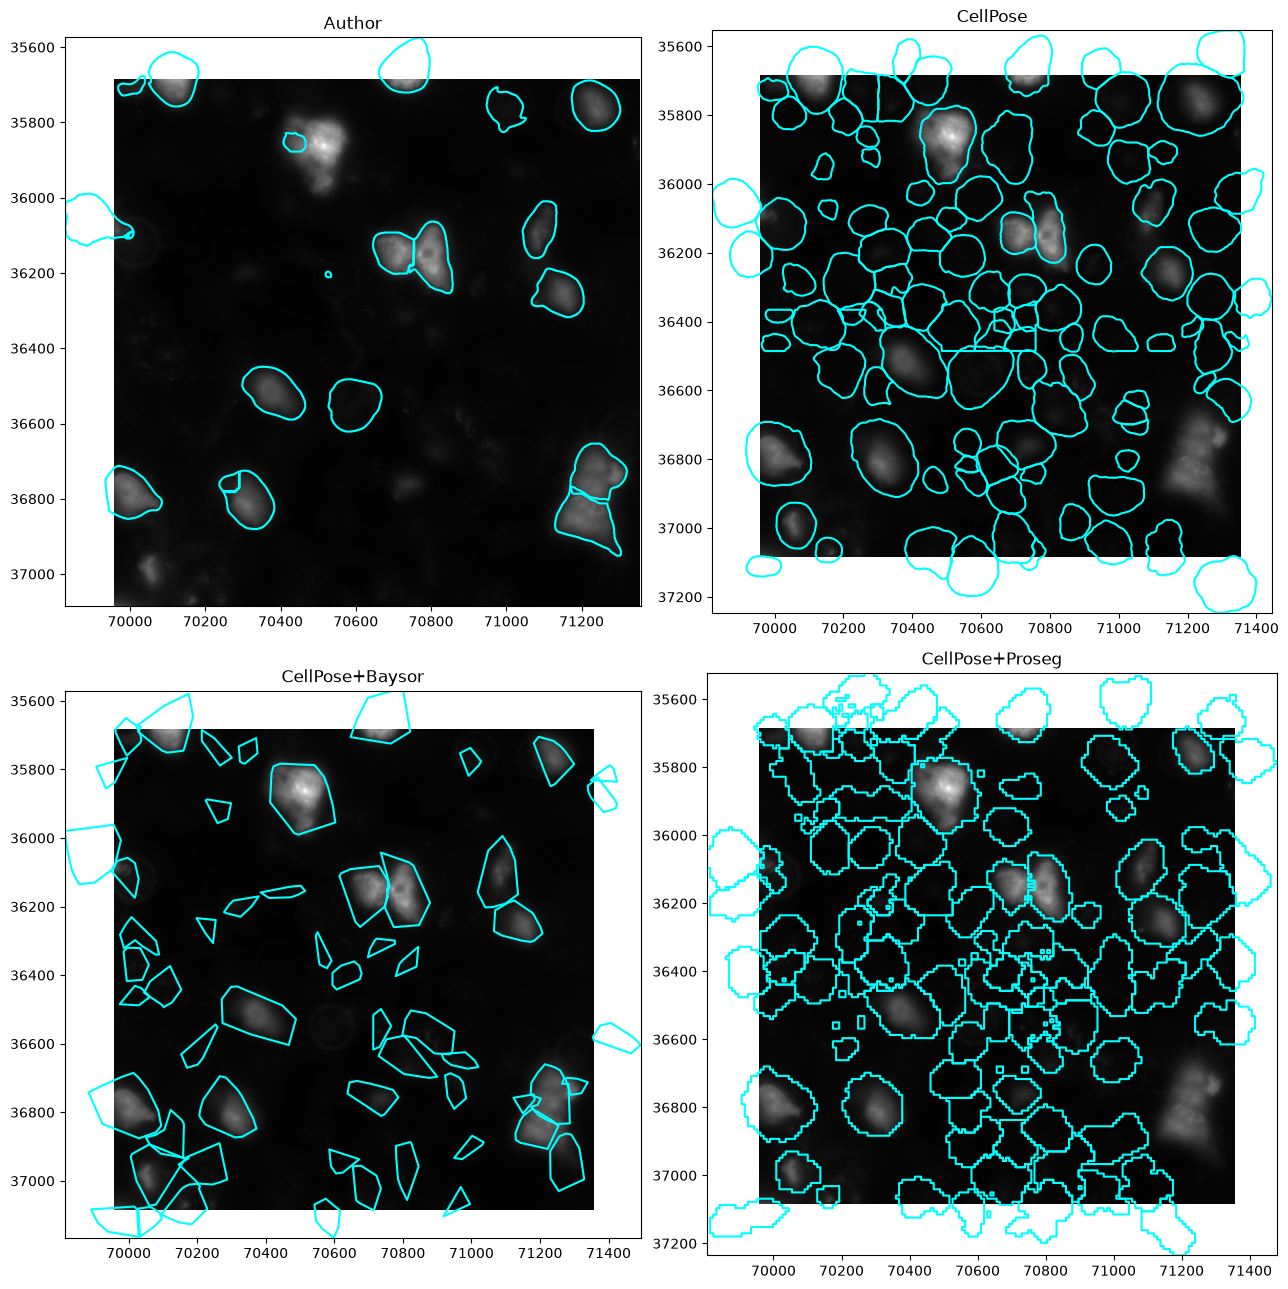

In [6]:
# a small window in the centre of the crop
ext = sd.get_extent(sdata[image_key], coordinate_system="global")
cx = 0.5 * (ext["x"][0] + ext["x"][1])
cy = 0.5 * (ext["y"][0] + ext["y"][1])
half = 700  # pixels (~75 um)
view = bounding_box_query(
    sdata, axes=("x", "y"), min_coordinate=[cx - half, cy - half],
    max_coordinate=[cx + half, cy + half], target_coordinate_system="global",
)

fig, axes = plt.subplots(2, 2, figsize=(13, 13))
for ax, (label, key) in zip(axes.ravel(), METHODS.items(), strict=True):
    (view.pl.render_images(image_key, channel="DAPI", cmap="gray", colorbar=False)
         .pl.render_shapes(key, fill_alpha=0, outline_alpha=1, outline_color="cyan")
         .pl.show(ax=ax, title=label))
fig.tight_layout()

❓ **Question.** Compare the four. Where does the **Author** watershed merge neighbouring
cells or miss nuclei? Do the transcript-aware methods (Baysor / Proseg) hug the cells more
tightly? Note what you see — we'll now test it quantitatively.

> ⚠️ **Note on the Author panel.** The staged vendor segmentation keeps only cells whose
> mask lies on the imaged **z-plane** (z3), so it looks *sparser* than it really is — many
> nuclei have no outline here. Don't read this as "watershed missed most cells": the fair
> comparison below is **per cell** (transcripts, purity), not the raw cell count.

## 4. High-level comparison

Following the [Sopa "compare segmentations" tutorial](https://prism-oncology.github.io/sopa/tutorials/compare_segmentations/),
we first compare **basic per-cell properties**. We build one cell × gene table per method
by aggregating transcripts **identically** (so the numbers are comparable), and look at:
number of cells, **transcripts per cell**, **genes per cell**, and **cell area**.

In [7]:
tables, areas = {}, {}
for label, key in METHODS.items():
    sopa.aggregate(sdata, shapes_key=key, aggregate_genes=True, aggregate_channels=False,
                   min_transcripts=0, key_added=f"{key}_table")
    ad = sdata[f"{key}_table"]
    ad.layers["counts"] = ad.X.copy()
    sc.pp.calculate_qc_metrics(ad, percent_top=None, log1p=False, inplace=True)
    tables[label] = ad
    # cell area in micron^2 (CellPose polygons are in pixels; the helper rescales)
    areas[label] = l1_utils.shapes_area_um2(sdata, key)

summary = pd.DataFrame({
    label: {
        "n_cells": tables[label].n_obs,
        "median transcripts/cell": np.median(tables[label].obs["total_counts"]),
        "median genes/cell": np.median(tables[label].obs["n_genes_by_counts"]),
        "median area (um^2)": np.median(areas[label]),
    }
    for label in METHODS
}).T.round(1)
summary

[INFO] (sopa.aggregation.transcripts) Aggregating transcripts over 444 cells


[                                        ] | 0% Completed | 164.31 us

[####################                    ] | 50% Completed | 106.58 ms

[########################################] | 100% Completed | 207.09 ms

/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the 

...

[########################################] | 100% Completed | 201.54 ms

/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the 

/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the 

/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C15/pixi/envs/spatialbrain-15357655127175290357/envs/default/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)


,n_cells,median transcripts/cell,median genes/cell,median area (um^2)
Author,444.0,68.0,32.0,98.8
CellPose,1225.0,5.0,4.0,94.7
CellPose+Baysor,906.0,44.0,27.0,80.4
CellPose+Proseg,903.0,24.0,17.0,171.0


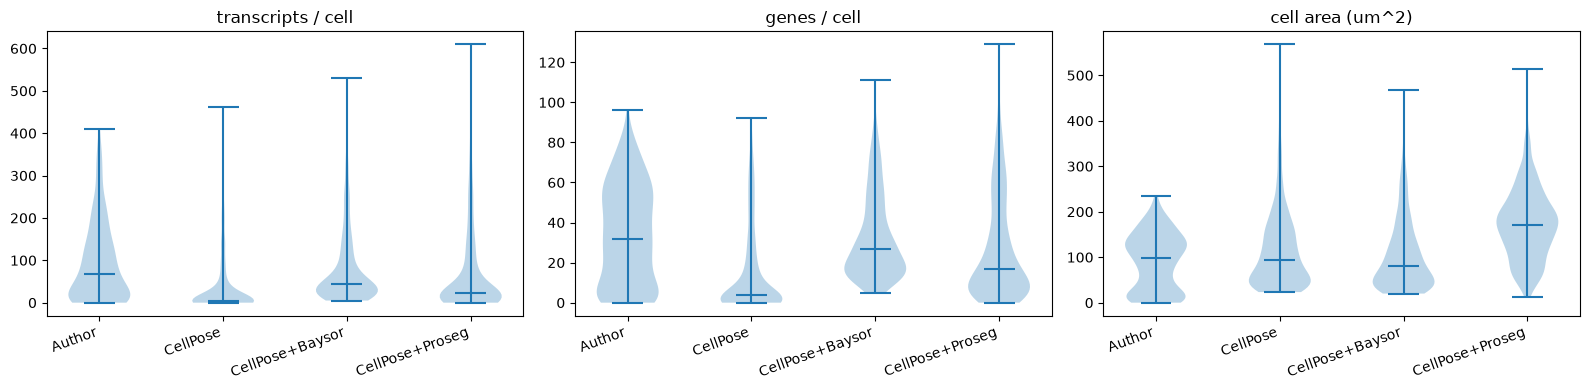

In [8]:
panels = [
    ("transcripts / cell", [tables[m].obs["total_counts"].to_numpy() for m in METHODS]),
    ("genes / cell", [tables[m].obs["n_genes_by_counts"].to_numpy() for m in METHODS]),
    ("cell area (um^2)", [areas[m] for m in METHODS]),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (title, data) in zip(axes, panels, strict=True):
    ax.violinplot(data, showmedians=True)
    ax.set_xticks(range(1, len(METHODS) + 1))
    ax.set_xticklabels(list(METHODS), rotation=20, ha="right")
    ax.set(title=title)
fig.tight_layout()

## 5. So — is the vendor segmentation actually good?

The four methods **disagree a lot**:

- **CellPose** finds the most "cells", but each has very few transcripts — it segments
  **nuclei** from DAPI only, so it misses the surrounding cytoplasm.
- The **Author** watershed and the transcript-aware methods return whole cells with far
  more transcripts per cell.

But here's the catch: **is "more transcripts per cell" a good thing, or contamination?**
A whole-cell method that **over-merges** neighbours pools their transcripts into one big
cell — high counts, but mixing different cell types. And are CellPose's tiny cells clean
**nuclei** or useless fragments? Counts and sizes alone **cannot tell over-splitting from
over-merging apart**. We need a metric that captures **both** failure modes — next.

## 6. A principled metric — negative-marker purity

**Idea (Salas et al.; ResolVI).** Some genes mark cell lineages that are *mutually
exclusive*: a neuron is not an oligodendrocyte, so a neuronal marker and an
oligodendrocyte marker should almost never be **on in the same cell**. When they are, it
means transcripts **leaked across a cell boundary** — a segmentation error.

- **y-axis — purity** = `1 − (mean cross-lineage double-positive rate)`. Higher is better.
  Each gene is called "on" per cell with a per-gene 2-component mixture (signal vs
  background), not a naive `count > 0`.
- **x-axis — transcripts per cell.** Purity on its own is gamed by **over-splitting**
  (tiny 1-transcript cells are trivially "pure"); transcripts/cell punishes that. Together
  the axes guard each other. **Best = upper-right.**

🔬 **Task 6.1** — provide a set of **mutually exclusive lineage markers** (present in the
300-gene panel). We give a canonical set below; you could also derive markers from a
reference atlas (`scanpy.tl.rank_genes_groups` per lineage, intersected with the panel).

> 📖 [Salas et al., *Genome Biology* 2022](https://doi.org/10.1186/s13059-022-02824-6) ·
> [txsim](https://github.com/theislab/txsim) · [ResolVI](https://github.com/YosefLab/resolvi-reproducibility).

In [9]:
lineage_markers = {
    "neuron": ["SATB2", "RBFOX3", "GAD1", "GAD2", "DLX2", "CAMK2A", "NEFL", "SLC6A1"],
    "astrocyte": ["AQP4", "GJA1", "SLC1A2", "GLUL"],
    "oligodendrocyte": ["PLP1", "MOBP", "UGT8", "ST18"],
    "vascular": ["CLDN5", "FLT1", "NRP1"],
    "immune": ["DOCK8", "APBB1IP", "DOCK10"],
}

scatter = {}
for label, ad in tables.items():
    purity, _ = l1_utils.negative_marker_purity(ad, lineage_markers, layer="counts")
    scatter[label] = (float(ad.obs["total_counts"].mean()), purity)

pd.DataFrame(scatter, index=["mean transcripts/cell", "purity"]).T.round(3)

,mean transcripts/cell,purity
Author,95.259,0.945
CellPose,39.269,0.954
CellPose+Baysor,82.469,0.950
CellPose+Proseg,71.808,0.944


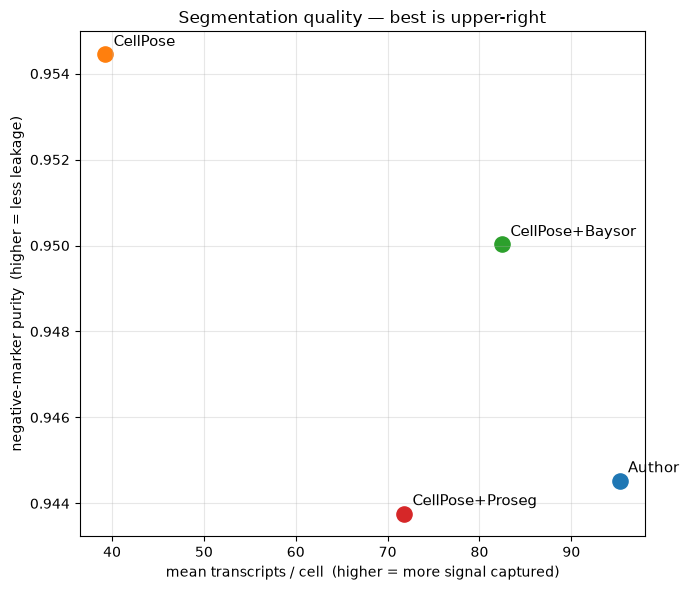

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
for label, (x, y) in scatter.items():
    ax.scatter(x, y, s=120)
    ax.annotate(label, (x, y), xytext=(6, 6), textcoords="offset points", fontsize=11)
ax.set(xlabel="mean transcripts / cell  (higher = more signal captured)",
       ylabel="negative-marker purity  (higher = less leakage)",
       title="Segmentation quality — best is upper-right")
ax.grid(alpha=0.3)
fig.tight_layout()

## 7. Conclusion

You made a **metric-backed** segmentation choice. Read the scatter:

- **CellPose → Baysor** sits furthest **upper-right** — nearly as many transcripts per cell
  as the whole-cell methods *and* high purity. On this crop, it wins the trade-off.
- The **Author** watershed is far right (most transcripts) but among the **lowest purity**:
  lots of signal, but more cross-lineage leakage — the signature of **over-merging**.
- **CellPose** alone is pure but transcript-starved (nuclei only — upper-left).
- **Proseg**, here, **over-expands** its cells (largest median area) and pays for it in
  purity — a reminder that even state-of-the-art methods must be checked and tuned on *your*
  data (recall the CellPose-GUI point: parameters are dataset-specific).

The lesson isn't that one method always wins — it's that the **default (vendor)
segmentation is not the best**, and you can only tell with a metric.
**Always sanity-check the segmentation before believing the cells.**

> ⚠️ This crop's segmentation is **not** carried into Level 2 — re-segmenting a single
> sample would batch-confound the full cohort, which starts fresh from the author
> segmentation. Level 1 is about *learning to judge* a segmentation.

### 🔬 Exercises
- **Parameters:** re-run CellPose via `l1_utils.run_cellpose(..., diameter=..., cellprob_threshold=...)`
  and watch the scatter move. Which direction does over-/under-segmentation push each axis?
- **Markers:** change `lineage_markers` (add a lineage, or bad/overlapping markers) and see
  how sensitive the purity metric is to *your* choices.
- **A fifth method:** Sopa also wraps **Stardist** and **ComSeg** — try adding one.

> 📖 [Sopa API tutorial](https://prism-oncology.github.io/sopa/tutorials/api_usage/) ·
> [squidpy](https://squidpy.readthedocs.io) for the spatial analyses coming in Level 2.